In [1]:
# building a Multi-Task NLP model using LSTM which can detect emotions , hate speech , violence , sarcasam in text.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
hate_df = pd.read_csv('/content/labeled_data.csv.zip')
hate_df

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [4]:
violence_df = pd.read_csv('/content/train.csv.zip')
viole_df= violence_df.copy()

In [5]:
# data loading

emotion_df = pd.read_csv('/content/text.csv.zip')
emotion_df


,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [6]:
violence_df.drop(columns = ['id'], inplace = True)
hate_df= hate_df[['tweet','class']]

In [7]:
emotion_df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [8]:
emotion_df

,Unnamed: 0,text,label
0,0,i just feel really helpless and heavy hearted,4
1,1,ive enjoyed being able to slouch about relax a...,0
2,2,i gave up my internship with the dmrg and am f...,4
3,3,i dont know i feel so lost,0
4,4,i am a kindergarten teacher and i am thoroughl...,4
...,...,...,...
416804,416804,i feel like telling these horny devils to find...,2
416805,416805,i began to realize that when i was feeling agi...,3
416806,416806,i feel very curious be why previous early dawn...,5
416807,416807,i feel that becuase of the tyranical nature of...,3


In [9]:
hate_df

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,1
24779,"you've gone and broke the wrong heart baby, an...",2
24780,young buck wanna eat!!.. dat nigguh like I ain...,1
24781,youu got wild bitches tellin you lies,1


In [10]:
emotion_df.columns

Index(['Unnamed: 0', 'text', 'label'], dtype='object')

In [11]:
hate_df.columns

Index(['tweet', 'class'], dtype='object')

In [12]:
print(violence_df['identity_hate'].value_counts())

identity_hate
0    158166
1      1405
Name: count, dtype: int64


In [13]:
violence_df.drop(columns = ['toxic','severe_toxic','obscene', 'threat', 'insult'],inplace=True)

In [14]:
#renaming columns

violence_df.rename(columns = {'comment_text':'text','identity_hate':'label'}, inplace = True)
hate_df.rename(columns = {'tweet':'text','class':'label'}, inplace = True)

/tmp/ipykernel_24585/4086726117.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hate_df.rename(columns = {'tweet':'text','class':'label'}, inplace = True)


In [15]:
emotion_df.columns, violence_df.columns, hate_df.columns

(Index(['Unnamed: 0', 'text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'),
 Index(['text', 'label'], dtype='object'))

In [16]:
#checking for null values
emotion_df.isnull().sum(), violence_df.isnull().sum(), hate_df.isnull().sum()

(Unnamed: 0    0
 text          0
 label         0
 dtype: int64,
 text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [17]:
emotion_df.shape , violence_df.shape, hate_df.shape

((416809, 3), (159571, 2), (24783, 2))

taking random 12000 datas from each dataset


In [18]:
emotion_df['label'].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


In [19]:
e_df = pd.DataFrame()

for i in range(6):
  subset = emotion_df[emotion_df['label'] == i].sample(n=2000,random_state = 42)
  e_df = pd.concat([e_df,subset])

In [20]:
emotion_df = e_df.copy()
emotion_df.shape

(12000, 3)

In [21]:
violence_df['label'].value_counts()

,count
label,
0,158166
1,1405


In [22]:
v_df = pd.DataFrame()

# Get all samples from the minority class (label 1)
subset_label_1 = violence_df[violence_df['label'] == 1]
v_df = pd.concat([v_df, subset_label_1])

# Sample from the majority class (label 0) to reach a total of 12000 samples
num_to_sample_from_label_0 = 12000 - len(subset_label_1)
subset_label_0 = violence_df[violence_df['label'] == 0].sample(n=num_to_sample_from_label_0, random_state=42)
v_df = pd.concat([v_df, subset_label_0])

In [23]:
violence_df = v_df.copy()
violence_df.shape

(12000, 2)

In [24]:
hate_df['label'].value_counts()

,count
label,
1,19190
2,4163
0,1430


In [25]:
offensive_speech = hate_df[hate_df['label'] == 1].sample(n=6407,random_state = 42)
hate_df = hate_df[hate_df['label'] != 1]

hate_df = pd.concat([offensive_speech,hate_df],axis=0)

hate_df.shape

(12000, 2)

In [26]:
emotion_df.reset_index(drop =True , inplace = True)
violence_df.reset_index(drop =True , inplace = True)
hate_df.reset_index(drop =True , inplace = True)


In [27]:
emotion_df.head()

,Unnamed: 0,text,label
0,133243,ive learned to surround myself with women who ...,0
1,88501,i already feel crappy because of this and you ...,0
2,131379,i feel like i have lost mourned and moved past...,0
3,148369,i could write a whole lot more about why im fe...,0
4,134438,i always seem to feel inadequate,0


In [28]:
violence_df.head(5)

,text,label
0,You are gay or antisemmitian? \n\nArchangel WH...,1
1,A pair of jew-hating weiner nazi schmucks.,1
2,I think that your a Fagget get a oife and burn...,1
3,"Kill all niggers. \n\nI have hard, that others...",1
4,u r a tw@ fuck off u gay boy.U r smelly.Fuck u...,1


In [29]:
hate_df.head(5)

,text,label
0,Why is it everytime I go to cracker barrel the...,1
1,"Run that nigga, you don't want that nigga, but...",1
2,I need a girl from Jamaica I can't fuck with t...,1
3,RT @ShadowBeatz_Inc: I know you have me blocke...,1
4,Put ya hands up if you a Grade A bitch,1


In [30]:
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [31]:
label_encoder = LabelEncoder()
violence_df['label'] = label_encoder.fit_transform(violence_df['label'])

In [32]:
violence_df['label'].unique()

array([1, 0])

In [33]:
# stopwords removal

In [34]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [35]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [36]:
# loading the stopwords

stop_words = set(stopwords.words('english'))
len(stop_words)

198

In [37]:
# stop word removal

def remv_stopwords(text):
  all_words = nltk.word_tokenize(text)
  filtered_words = [word for word in all_words if word.lower() not in stop_words]
  return ' '.join(filtered_words)

emotion_df['text'] = emotion_df['text'].apply(remv_stopwords)
violence_df['text'] = violence_df['text'].apply(remv_stopwords)
hate_df['text'] = hate_df['text'].apply(remv_stopwords)

In [38]:
# tokenization and padding

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [39]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(pd.concat ([emotion_df['text'],violence_df['text'],hate_df['text']],axis=0))


In [40]:
emotion_sequences = tokenizer.texts_to_sequences(emotion_df['text'])
violence_sequences = tokenizer.texts_to_sequences(violence_df['text'])
hate_sequences = tokenizer.texts_to_sequences(hate_df['text'])

In [41]:
emotion_df['text'].iloc[2]

'feel like lost mourned moved past tears relationship'

In [42]:
emotion_sequences[2:3]

[[2, 5, 551, 25874, 805, 436, 2623, 1051]]

In [43]:
max_length = 50
emotion_padded = pad_sequences(emotion_sequences,maxlen = max_length,padding = 'post')
violence_padded = pad_sequences(violence_sequences,maxlen = max_length,padding = 'post')
hate_padded = pad_sequences(hate_sequences,maxlen = max_length,padding = 'post')

In [44]:
emotion_padded[2:3]

array([[    2,     5,   551, 25874,   805,   436,  2623,  1051,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0]], dtype=int32)

In [45]:
#generating labels in numpy array format

emotion_labels = np.array(emotion_df['label'])
violence_labels = np.array(violence_df['label'])
hate_labels = np.array(hate_df['label'])

In [46]:
# Model defination

#prepare separate inputs for each dataset

emotion_input = emotion_padded
violence_input = violence_padded
hate_input = hate_padded

In [47]:
#defining multiple input layers for each task

from tensorflow import keras

emotion_input_layer = keras.layers.Input(shape=(max_length,), name = 'emotion_df')
violence_input_layer = keras.layers.Input(shape=(max_length,), name = 'violence_df')
hate_input_layer = keras.layers.Input(shape=(max_length,), name = 'hate_df')

In [48]:
#use as shared embedding layer

embedding_layer = keras.layers.Embedding(input_dim = len(tokenizer.word_index)+1, output_dim =  128)

In [49]:
# apply the embedding layer to each input

emotion_embedded = embedding_layer(emotion_input_layer)
violence_embedded = embedding_layer(violence_input_layer)
hate_embedded = embedding_layer(hate_input_layer)

In [50]:
#shared LSTM layer

shared_lstm = keras.layers.LSTM(64 , return_sequences= True)

In [51]:
emotion_lstm = shared_lstm(emotion_embedded)
violence_lstm = shared_lstm(violence_embedded)
hate_lstm = shared_lstm(hate_embedded)

In [52]:
#shared global average pooling layer

shared_global_average_pooling = keras.layers.GlobalAveragePooling1D()
shared_dropout = keras.layers.Dropout(0.5)


In [53]:
emotion_features = shared_dropout(shared_global_average_pooling(emotion_lstm))
violence_features = shared_dropout(shared_global_average_pooling(violence_lstm))
hate_features = shared_dropout(shared_global_average_pooling(hate_lstm))

In [54]:
len(emotion_df['label'].unique()) , len(violence_df['label'].unique()) , len(hate_df['label'].unique())

(6, 2, 3)

In [55]:
#output layers

emotion_output = keras.layers.Dense(6 , activation = 'softmax' , name = 'emotion_output')(emotion_features)
violence_output = keras.layers.Dense(2 , activation = 'softmax' , name = 'violence_output')(violence_features)
hate_output = keras.layers.Dense(3 , activation = 'softmax' , name = 'hate_output')(hate_features)

In [56]:
#compile the model with multiple input and outputs

model = keras.models.Model(inputs = [emotion_input_layer,violence_input_layer,hate_input_layer],
                           outputs = [emotion_output,violence_output,hate_output])

model . compile(optimizer = 'adam', loss = {'emotion_output' : 'sparse_categorical_crossentropy',
                                            'violence_output' : 'sparse_categorical_crossentropy',
                                            'hate_output': 'sparse_categorical_crossentropy'},
                metrics = {
                    'emotion_output' : 'accuracy',
                    'violence_output' : 'accuracy',
                    'hate_output': 'accuracy'
                })

In [57]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ emotion_df          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_df         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_df             │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  7,564,800 │ emotion_df[0][0], │
│ (Embedding)         │                   │            │ violence_df[0][0… │
│                     │                   │            │ hate_df[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 50, 64)    │     49,408 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0],  │
│                     │                   │            │ embedding[2][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ lstm[0][0],       │
│ (GlobalAveragePool… │                   │            │ lstm[1][0],       │
│                     │                   │            │ lstm[2][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
│                     │                   │            │ global_average_p… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 6)         │        390 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ violence_output     │ (None, 2)         │        130 │ dropout[1][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hate_output (Dense) │ (None, 3)         │        195 │ dropout[2][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,614,923 (29.05 MB)

 Trainable params: 7,614,923 (29.05 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
#training the model with separate inputs

model.fit(x = {'emotion_df' : emotion_input, 'violence_df' : violence_input, 'hate_df' : hate_input },
          y = {'emotion_output' : emotion_labels, 'violence_output' : violence_labels, 'hate_output' : hate_labels },
          epochs = 10,
          batch_size = 4)

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 59s 17ms/step - emotion_output_accuracy: 0.3744 - emotion_output_loss: 1.4937 - hate_output_accuracy: 0.7532 - hate_output_loss: 0.6226 - loss: 2.3447 - violence_output_accuracy: 0.9152 - violence_output_loss: 0.2284
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - emotion_output_accuracy: 0.8874 - emotion_output_loss: 0.3848 - hate_output_accuracy: 0.8818 - hate_output_loss: 0.3323 - loss: 0.8211 - violence_output_accuracy: 0.9622 - violence_output_loss: 0.1040
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 16ms/step - emotion_output_accuracy: 0.9467 - emotion_output_loss: 0.1742 - hate_output_accuracy: 0.9310 - hate_output_loss: 0.1961 - loss: 0.4212 - violence_output_accuracy: 0.9822 - violence_output_loss: 0.0509
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 49s 16ms/step - emotion_output_accuracy: 0.9615 - emotion_output_loss: 0.1156 - hate_output_accuracy: 0.9674 - hate_output_loss: 0.0983 - loss: 0.2422 - violence_output_accuracy: 0.

In [59]:
#prediction and evaluation

prediction = model.predict({'emotion_df' : emotion_input, 'violence_df' : violence_input, 'hate_df' : hate_input })

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [60]:
prediction

[array([[9.9997222e-01, 4.1153430e-06, 5.7357391e-07, 1.5753756e-05,
         6.4554829e-06, 8.0024768e-07],
        [9.9999881e-01, 3.9417392e-07, 1.0700156e-08, 6.4305391e-07,
         2.1456775e-07, 7.5160926e-08],
        [9.9999619e-01, 4.2903881e-07, 1.5350279e-08, 2.3708185e-06,
         4.6167193e-07, 4.3337980e-07],
        ...,
        [1.2816703e-04, 2.0695852e-04, 4.0798609e-06, 1.8904178e-04,
         1.5652070e-02, 9.8381978e-01],
        [4.7818901e-07, 7.8153420e-07, 1.4348139e-08, 2.0810346e-06,
         7.1737209e-06, 9.9998951e-01],
        [7.2703028e-06, 2.7900052e-05, 1.0384816e-06, 9.7848817e-05,
         3.4529163e-05, 9.9983132e-01]], dtype=float32),
 array([[1.7729350e-05, 9.9998224e-01],
        [4.5906695e-06, 9.9999535e-01],
        [2.8319462e-07, 9.9999976e-01],
        ...,
        [9.9997866e-01, 2.1340289e-05],
        [9.9999976e-01, 2.9583933e-07],
        [1.0000000e+00, 3.2895471e-08]], dtype=float32),
 array([[1.7231824e-06, 9.9999404e-01, 4.33254

In [61]:
emotion_pred = np.argmax(prediction[0],axis = 1)
violence_pred = np.argmax(prediction[1],axis = 1)
hate_pred = np.argmax(prediction[2],axis = 1)

In [62]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


def plot_confusion_matrix(y_true, y_pred, title , labels):
    cm = confusion_matrix(y_true, y_pred , normalize = 'true')
    plt.figure(figsize=(7,6))
    sns.heatmap(cm , annot = True , cmap = 'Blues' , xticklabels=labels , yticklabels = labels )
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


In [63]:
emotion_labels_text = ['sadness','joy','love','anger','fear','surprise']
violence_labels_text = ['violence','not_violence']
hate_labels_text = ['offensive_language','neither','hate_speech',]

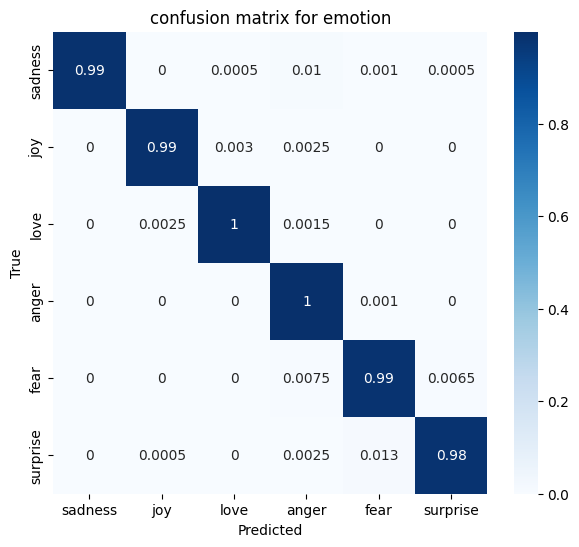

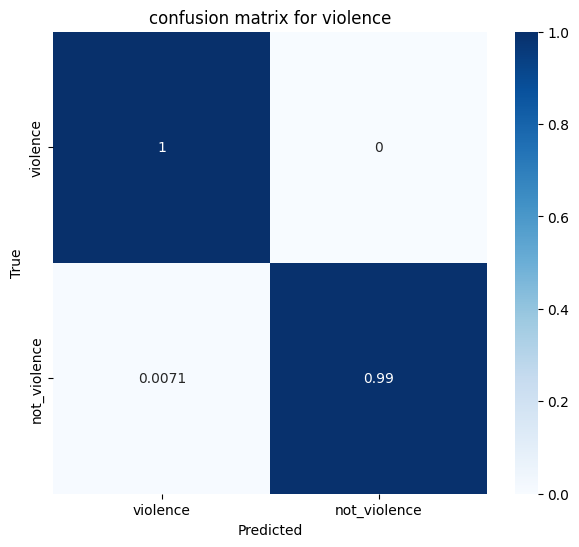

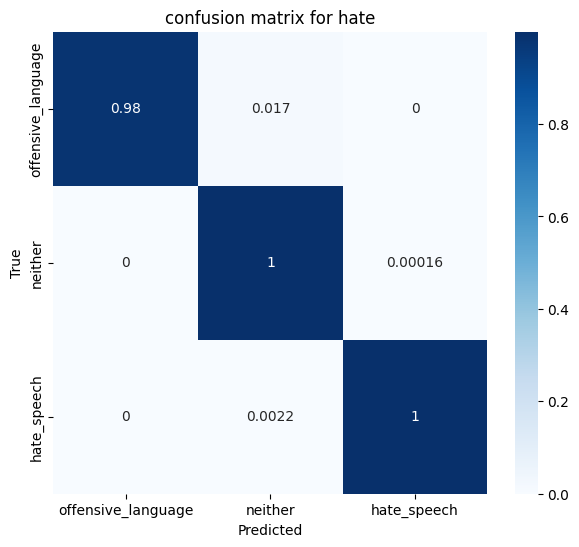

In [64]:
plot_confusion_matrix(emotion_labels,emotion_pred,'confusion matrix for emotion', emotion_labels_text)
plot_confusion_matrix(violence_labels,violence_pred,'confusion matrix for violence', violence_labels_text)
plot_confusion_matrix(hate_labels,hate_pred,'confusion matrix for hate', hate_labels_text)

MANUAL TESTING

In [65]:
def classify_text(input_text):

  #preprocess the input text
  input_text_cleaned = remv_stopwords(input_text)
  input_sequence = tokenizer.texts_to_sequences([input_text_cleaned])
  input_padded = pad_sequences(input_sequence,maxlen = max_length,padding = 'post')

  #prediction - pass the single input_padded to all three input layers
  prediction = model.predict({
      'emotion_df' : input_padded,
      'violence_df' : input_padded,
      'hate_df' : input_padded
  })

  # Get single integer prediction for each task
  emotion_pred_idx = np.argmax(prediction[0][0])
  violence_pred_idx = np.argmax(prediction[1][0])
  hate_pred_idx = np.argmax(prediction[2][0])

  #determine major label (based on highest confidence across tasks)
  major_labels = ['emotion','violence','hate']
  major_label_index = np.argmax([np.max(prediction[0][0]), np.max(prediction[1][0]), np.max(prediction[2][0])])
  major_label = major_labels[major_label_index]

  #determine the sublabels
  emotion_labels_text = ['sadness','joy','love','anger','fear','surprise']
  # Corrected order: 0 for not_violence, 1 for violence based on value_counts and label_encoder
  violence_labels_text = ['not_violence','violence']
  # Corrected order: 0 for hate_speech, 1 for offensive_language, 2 for neither based on value_counts
  hate_labels_text = ['hate_speech','offensive_language','neither']

  if major_label == 'emotion':
    sublabel = emotion_labels_text[emotion_pred_idx]
  elif major_label == 'violence':
    sublabel = violence_labels_text[violence_pred_idx]
  else: # major_label == 'hate'
    sublabel = hate_labels_text[hate_pred_idx]

  return major_label , sublabel


In [66]:
import ipywidgets as widgets
from IPython.display import display

In [67]:
#define a text widget and a placeholder

input_text_widget = widgets.Text(
    description = 'Enter Text:',
    placeholder = 'Type your text here'
)

In [68]:
#define classify buttton

button = widgets.Button(description = 'classify')

In [69]:
#define an output area to dispaly result

output = widgets.Output()

In [70]:
#function to handle event

def on_button_click(b):
  with output:
    output.clear_output()    #clear prev. o/p
    input_text = input_text_widget.value
    major_label , sublabel = classify_text(input_text)
    print(f'Major label: {major_label}')
    print(f'Sublabel: {sublabel}')

In [71]:
#attach the button at bottom

button.on_click(on_button_click)


In [72]:
display(input_text_widget,button,output)

Text(value='', description='Enter Text:', placeholder='Type your text here')

Button(description='classify', style=ButtonStyle())

Output()